# Split-window LST: minimal prediction example

## Goal
Apply **frozen coefficients only**: 18 algorithms, Grouping / Parameterization,
and clean-input / uncertainty-aware calibration. No training or coefficient estimation.

This fixed 10,000-row illustration (clean and perturbed inputs) is not an independent holdout and
does not reproduce full-dataset manuscript RMSE. Calibration labels identify the
archived coefficient sets, distinct from the input-noise scenarios tested below.


## Setup and data
Run from this folder after `python -m pip install -r requirements.txt`.
Temperatures: K; emissivities: dimensionless; WVC: g/cm^2;
`sec_vza = 1/cos(VZA)` in [1, 2], not degrees.
Bias is **prediction minus reference**. See README for coefficient conventions.


In [1]:
from pathlib import Path
import warnings
warnings.filterwarnings("ignore", message="Pandas requires version.*bottleneck")
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from predict import predict, metrics, MODELS, STRATEGIES, CALIBRATIONS
from perturb import perturb_inputs

ROOT = Path.cwd()
OUTPUT = ROOT / "outputs"
OUTPUT.mkdir(exist_ok=True)
data = pd.read_csv(ROOT / "data/simulation_sample_10000.csv")
assert len(data) == 10000
display(data.head())
display(data.groupby("sec_vza").size().rename("N").to_frame())

,T31_K,T32_K,emissivity31,emissivity32,wvc_g_cm2,sec_vza,LST_reference_K
0,295.689633,294.571486,0.965637,0.973705,3.901269,1.0,301.86
1,298.618732,296.926043,0.972277,0.978400,3.901269,1.0,306.86
2,286.676456,286.755686,0.971515,0.970044,2.692389,1.0,287.73
3,274.606116,275.178338,0.983155,0.952914,2.500555,1.0,271.81
4,298.333798,297.372764,0.951066,0.970656,2.500555,1.0,306.81


,N
sec_vza,
1.0,1667
1.2,1667
1.4,1667
1.6,1667
1.8,1666
2.0,1666


## A single prediction call
The function only uses six input columns. `LST_reference_K` is used below for evaluation,
never for prediction or Grouping bin selection. The default Grouping angle mode
evaluates frozen quadratic polynomials; `angle_mode="nodes"` selects exact archived
node coefficients and can give different results even at original angles.
Grouping retains overlapping bins: later matching bins overwrite earlier ones,
rather than averaging their predictions. All bins are lower-inclusive / upper-exclusive.


In [2]:
predicted = predict(data, model="GA2008", strategy="parameterization", calibration="clean")
display(pd.DataFrame({"reference_K": data.LST_reference_K, "predicted_K": predicted}).head())
metrics(data.LST_reference_K.to_numpy(), predicted)

,reference_K,predicted_K
0,301.86,301.638403
1,306.86,306.658720
2,287.73,287.449411
3,271.81,271.170974
4,306.81,306.669923


{'N_total': 10000,
 'N_valid': 10000,
 'Bias_K': 0.005883470592567127,
 'RMSE_K': 0.5403264211289913}

## One input-noise realization
Gaussian standard deviations: BT **0.05 K** in each band, emissivity **0.01** in each
band, and WVC **10% of its original value**. Errors are drawn independently and
then emissivity is clipped to [0, 0.999], WVC to [0, 9.99] g/cm^2, matching TD-All.
The seed is fixed to 20260929. All algorithms share the same perturbed inputs;
reference LST and viewing angle are unchanged. No coefficients are updated.
This is one realization, not a Monte Carlo uncertainty interval.


In [3]:
noisy_data = perturb_inputs(data, seed=20260929)
noisy_data.to_csv(ROOT / "data/simulation_sample_10000_noisy.csv", index=False, float_format="%.17g")
columns = ["T31_K", "T32_K", "emissivity31", "emissivity32", "wvc_g_cm2"]
display((noisy_data[columns] - data[columns]).agg(["mean", "std"]).T)
scenarios = {"TD-Clear": data, "TD-All": noisy_data}

,mean,std
T31_K,0.000372,0.049968
T32_K,-0.000308,0.050589
emissivity31,0.000001,0.009941
emissivity32,0.000034,0.009813
wvc_g_cm2,-0.002174,0.184363


## Bias and RMSE across algorithms
All combinations use the same 10,000 reference rows. Missing predictions
are excluded pairwise and explicitly counted; check N_valid before comparing metrics.


In [4]:
records = []
for scenario, inputs in scenarios.items():
    for strategy in STRATEGIES:
        for calibration in CALIBRATIONS:
            for model in MODELS:
                p = predict(inputs, model=model, strategy=strategy, calibration=calibration)
                records.append(dict(scenario=scenario, strategy=strategy, calibration=calibration, model=model,
                                    **metrics(data.LST_reference_K.to_numpy(), p)))
results = pd.DataFrame(records)
results.to_csv(OUTPUT / "sample_metrics.csv", index=False)
display(results.groupby(["scenario", "strategy", "calibration"])[["N_valid", "RMSE_K", "Bias_K"]].agg(["min", "max"]).round(4))

N_valid         RMSE_K          \
                                                min    max     min     max   
scenario strategy         calibration                                        
TD-All   grouping         clean               10000  10000  1.1049  2.2625   
                          uncertainty_aware   10000  10000  0.9876  1.3753   
         parameterization clean               10000  10000  1.5329  2.3849   
                          uncertainty_aware   10000  10000  0.9921  1.1228   
TD-Clear grouping         clean               10000  10000  0.5194  1.2749   
                          uncertainty_aware   10000  10000  0.7443  1.2780   
         parameterization clean               10000  10000  0.5280  0.7426   
                          uncertainty_aware   10000  10000  0.7426  0.8722   

                                             Bias_K          
                                                min     max  
scenario strategy         calibration                        
TD-All   grouping         clean             -0.1836  0.0964  
                          uncertainty_aware -0.1549 -0.0059  
         parameterization clean             -0.0155  0.1147  
                          uncertainty_aware -0.0069  0.0045  
TD-Clear grouping         clean             -0.1712  0.0628  
                          uncertainty_aware -0.1491 -0.0074  
         parameterization clean             -0.0036  0.0076  
                          uncertainty_aware  0.0064  0.0410

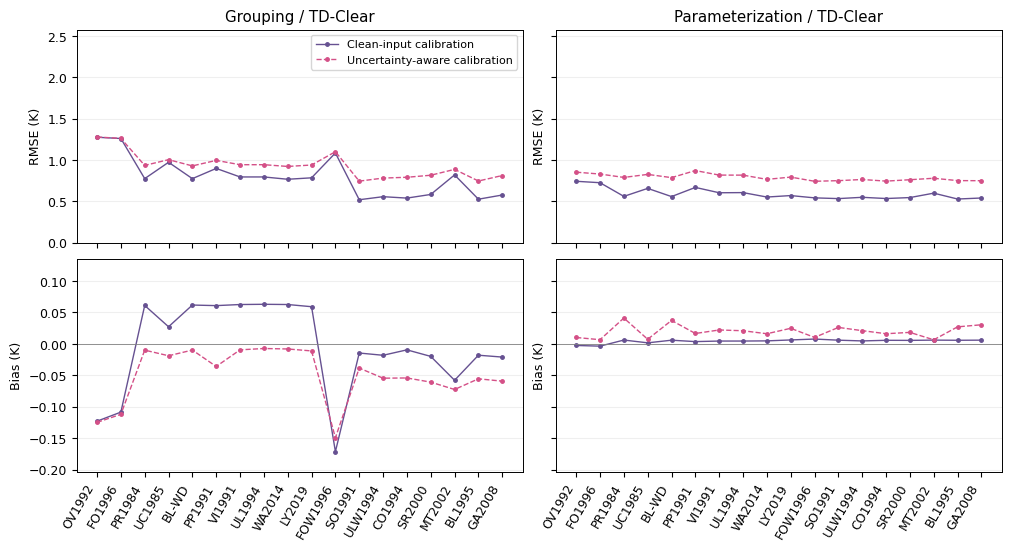

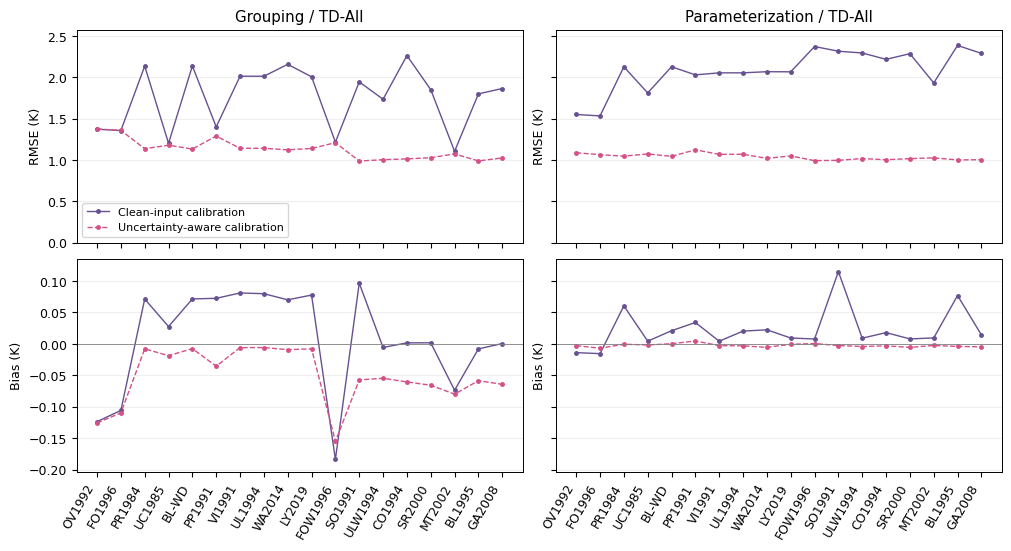

In [5]:
plt.rcParams.update({"font.family": "DejaVu Sans", "font.size": 9,
                     "axes.linewidth": 0.7, "pdf.fonttype": 42})
colors = {"clean": "#665191", "uncertainty_aware": "#D45087"}
labels = {"clean": "Clean-input calibration", "uncertainty_aware": "Uncertainty-aware calibration"}
x = np.arange(len(MODELS))
for scenario in scenarios:
    fig, axes = plt.subplots(2, 2, figsize=(10, 5.4), sharex=True, sharey="row", constrained_layout=True)
    for col, strategy in enumerate(STRATEGIES):
        for calibration in CALIBRATIONS:
            values = results[(results.scenario == scenario) & (results.strategy == strategy) & (results.calibration == calibration)].set_index("model").loc[list(MODELS)]
            for row, metric in enumerate(["RMSE_K", "Bias_K"]):
                axes[row, col].plot(x, values[metric], color=colors[calibration],
                                   linestyle="-" if calibration == "clean" else "--",
                                   marker="o", markersize=2.5, linewidth=1, label=labels[calibration])
        axes[0, col].set_title(strategy.capitalize() + " / " + scenario)
        axes[0, col].set_ylim(0, results.RMSE_K.max() * 1.08)
        bias_lo, bias_hi = min(0, results.Bias_K.min()), max(0, results.Bias_K.max())
        axes[1, col].set_ylim(bias_lo - .02, bias_hi + .02)
        axes[1, col].axhline(0, color="0.5", linewidth=.6)
        axes[1, col].set_xticks(x, MODELS, rotation=60, ha="right")
        for row in range(2):
            axes[row, col].set_ylabel("RMSE (K)" if row == 0 else "Bias (K)")
            axes[row, col].grid(axis="y", alpha=.2)
    axes[0, 0].legend(fontsize=8)
    stem = "bias_rmse" if scenario == "TD-Clear" else "bias_rmse_noisy"
    fig.savefig(OUTPUT / (stem + ".png"), dpi=240)
    fig.savefig(OUTPUT / (stem + ".pdf"))
    plt.show()

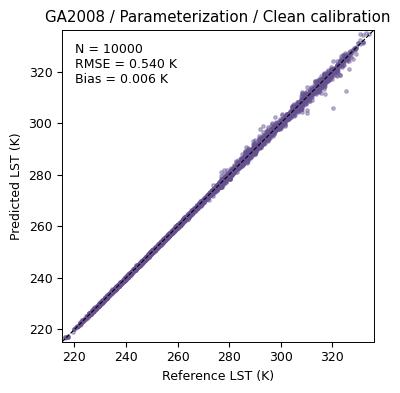

In [6]:
fig, ax = plt.subplots(figsize=(4.5, 4))
ax.scatter(data.LST_reference_K, predicted, s=6, alpha=.4, color="#665191", rasterized=True)
limits = [min(data.LST_reference_K.min(), predicted.min()) - 1,
          max(data.LST_reference_K.max(), predicted.max()) + 1]
ax.plot(limits, limits, "k--", linewidth=.8)
ax.set(xlim=limits, ylim=limits, xlabel="Reference LST (K)", ylabel="Predicted LST (K)",
       title="GA2008 / Parameterization / Clean calibration")
ax.set_aspect("equal")
score = metrics(data.LST_reference_K.to_numpy(), predicted)
ax.text(.04, .96, f"N = {score['N_valid']}\nRMSE = {score['RMSE_K']:.3f} K\nBias = {score['Bias_K']:.3f} K",
        transform=ax.transAxes, va="top")
fig.tight_layout()
fig.savefig(OUTPUT / "example_scatter.png", dpi=240)
fig.savefig(OUTPUT / "example_scatter.pdf")
plt.show()

## Interpretation
These plots verify a small, portable prediction workflow. They do not establish
an independent test-set accuracy or reproduce the full manuscript experiment.
Uncertainty-aware coefficients need not outperform clean-input coefficients on clean inputs.
Do not extrapolate beyond the documented angle/WVC range or silently discard uncovered rows.
